In [4]:
# STEP 0: Install dependencies (Colab only)
# !pip install scipy matplotlib torch torchvision

# STEP 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


In [5]:
# STEP 2: Generate Synthetic Signal (3 activities/segments)
def generate_synthetic_signal():
    t = np.linspace(0, 10, 1000)
    seg1 = np.sin(2 * np.pi * 1 * t[:300]) + np.random.normal(0, 0.2, 300)  # Activity A
    seg2 = np.sin(2 * np.pi * 3 * t[300:700]) + 3 + np.random.normal(0, 0.2, 400)  # Activity B
    seg3 = np.sin(2 * np.pi * 5 * t[700:]) + 6 + np.random.normal(0, 0.2, 300)  # Activity C
    signal = np.concatenate([seg1, seg2, seg3])
    labels = np.array([0]*300 + [1]*400 + [2]*300)
    return signal, labels

raw_signal, true_labels = generate_synthetic_signal()

In [6]:
# STEP 3: Denoising (Butterworth filter)
def butter_lowpass_filter(data, cutoff=3.0, fs=100.0, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

denoised_signal = butter_lowpass_filter(raw_signal)

In [7]:
# STEP 4: Normalization
norm_signal = (denoised_signal - np.mean(denoised_signal)) / np.std(denoised_signal)


In [8]:
# STEP 5: Prepare Dataset
window_size = 50
stride = 5

X, y = [], []
for i in range(0, len(norm_signal) - window_size, stride):
    X.append(norm_signal[i:i+window_size])
    y.append(np.bincount(true_labels[i:i+window_size]).argmax())  # Majority label

X = np.array(X)
y = np.array(y)

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # [N, 1, window]
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [9]:
# STEP 6: FR-DCNN Model Definition
class FRDCNN(nn.Module):
    def __init__(self):
        super(FRDCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

model = FRDCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# STEP 7: Train Model
for epoch in range(10):
    for batch_X, batch_y in loader:
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.9229
Epoch 2, Loss: 0.7339
Epoch 3, Loss: 0.5673
Epoch 4, Loss: 0.5369
Epoch 5, Loss: 0.4127
Epoch 6, Loss: 0.3350
Epoch 7, Loss: 0.2795
Epoch 8, Loss: 0.2450
Epoch 9, Loss: 0.2061
Epoch 10, Loss: 0.2309


In [11]:
# STEP 8: Inference on Full Signal (Sliding Window)
model.eval()
all_preds = []

for i in range(0, len(norm_signal) - window_size, 1):
    window = norm_signal[i:i+window_size]
    x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        pred = model(x).argmax(dim=1).item()
    all_preds.append(pred)

all_preds = np.array(all_preds)
# Pad to original length
predicted_labels = np.pad(all_preds, (window_size//2, len(norm_signal)-len(all_preds)-window_size//2), mode='edge')



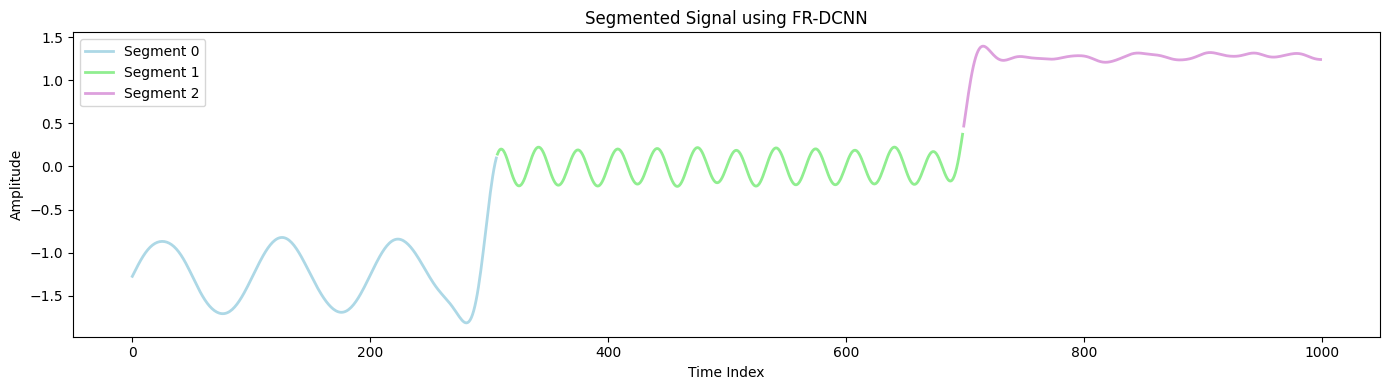

In [12]:
# STEP 9: Visualization
colors = ['lightblue', 'lightgreen', 'plum']
fig, ax = plt.subplots(figsize=(14, 4))

for label in np.unique(predicted_labels):
    indices = np.where(predicted_labels == label)[0]
    ax.plot(indices, norm_signal[indices], color=colors[label], label=f'Segment {label}', linewidth=2)

ax.set_title('Segmented Signal using FR-DCNN')
ax.set_xlabel('Time Index')
ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.show()

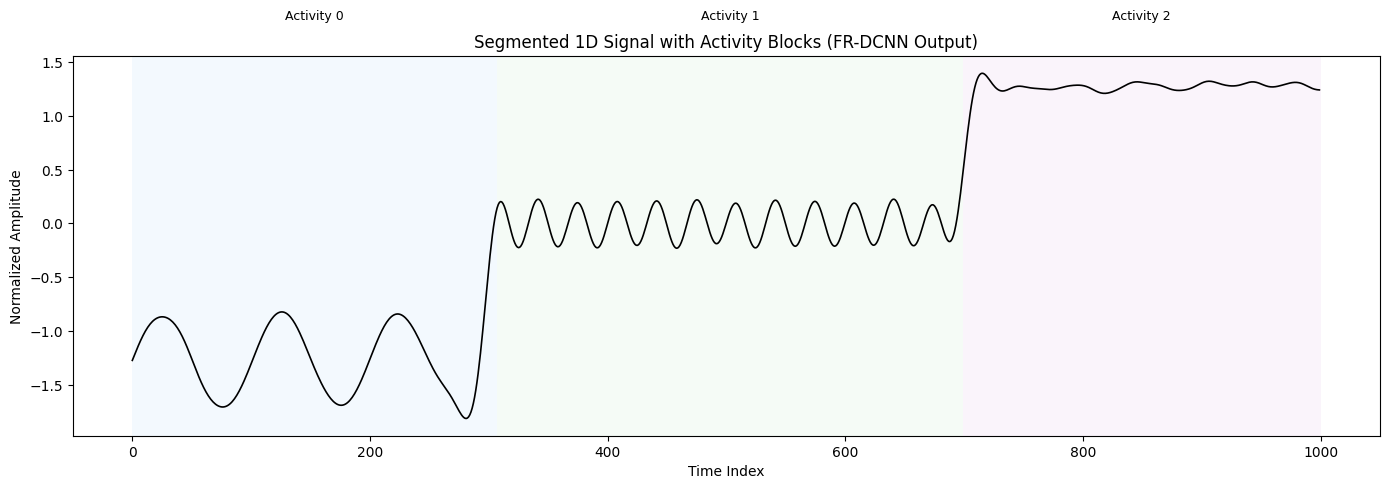

In [14]:
# STEP 9: Enhanced Visualization (Activity Blocks)

import matplotlib.pyplot as plt

# Define activity segment colors
background_colors = ['#e3f2fd', '#e8f5e9', '#f3e5f5']
line_color = 'black'

fig, ax = plt.subplots(figsize=(14, 5))

# Draw background colors for each activity segment
current_label = predicted_labels[0]
start_idx = 0

for i in range(1, len(predicted_labels)):
    if predicted_labels[i] != current_label:
        ax.axvspan(start_idx, i, facecolor=background_colors[current_label % len(background_colors)], alpha=0.4)
        ax.text((start_idx + i)//2, max(norm_signal)+0.5, f"Activity {current_label}", ha='center', fontsize=9)
        start_idx = i
        current_label = predicted_labels[i]

# Add last segment
ax.axvspan(start_idx, len(predicted_labels), facecolor=background_colors[current_label % len(background_colors)], alpha=0.4)
ax.text((start_idx + len(predicted_labels))//2, max(norm_signal)+0.5, f"Activity {current_label}", ha='center', fontsize=9)

# Plot raw signal
ax.plot(norm_signal, color=line_color, linewidth=1.2)

# Labels and legend
ax.set_title("Segmented 1D Signal with Activity Blocks (FR-DCNN Output)")
ax.set_xlabel("Time Index")
ax.set_ylabel("Normalized Amplitude")
plt.tight_layout()
plt.show()
